In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurar la ruta para importar 'Source'
# Agregamos la carpeta raíz al path de Python
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

# 2. Activar Autoreload (Vital para desarrollo)
%load_ext autoreload
%autoreload 2

# 3. Importar tus clases de FEM
from Source.Pre_processing.Mesh import Mesh
from Source.core import Model
from Source.Material import material
from Source.Physics.MassTransfer import mt

from Source.enums import ElementType, ShapeFunctionType, StudyType, ProblemType, SolverType, DirectSolvers

print("Entorno FEM-Sim cargado correctamente.")

Entorno FEM-Sim cargado correctamente.


In [2]:
# Defining problem dimension: 1D
PD = 1 

# Create mesh from linear element
L = 1  # Length size of the domain [m]
NoE = 10  # Number of Elements
MeshType = ElementType.line  # Type of element
shapeFunction = ShapeFunctionType.linear  # Shape function for spatial discretization

In [3]:
Mesh1 = Mesh()
Mesh1.Generate_Mesh(PD, L, NoE, MeshType)
Mesh1.setElementShapeFunction(shapeFunction)

Mesh1.defineBoundary('inlet', 0)
Mesh1.defineBoundary('outlet', NoE) # Hardcoded

In [4]:
Mat1 = material('Media', k = 0.2, miu=1, rho=1, Cp= 1)

In [5]:
Model1 = Model(name='Diff_reaction_problem', mtype=None, dim=PD, mesh=Mesh1, mat=Mat1, psc=mt)

Model1.physics.setChemSpecies('A', 'Component A')
Model1.physics.setChemSpecies('B', 'Component B')
Model1.physics.setChemSpecies('C', 'Component C')

Model1.physics.setDiffusivity('A', 1)
Model1.physics.setDiffusivity('B', 0.5)
Model1.physics.setDiffusivity('C', 2)

# Neglecting convection term
Model1.physics.Convection = True
Model1.physics.Stab = None

# Add Boundary condition
Model1.physics.addBC_Concentration(0, 'A', 30)
Model1.physics.addBC_Concentration(0, 'B', 20)
Model1.physics.addBC_Concentration(0, 'C', 1)

Model1.physics.addBC_Outflow(Mesh1.boundaries['outlet'], 'A')
Model1.physics.addBC_Outflow(Mesh1.boundaries['outlet'], 'B')
Model1.physics.addBC_Outflow(Mesh1.boundaries['outlet'], 'C')

# Add reaction
stoich = {'A': -1, 'B': -1, 'C': 1}
order = {'A': 1, 'B': 1, 'C': 0}
k0 = 10
E_R = 500
T = 300
Model1.physics.addReaction(stoich, k0, E_R, T, order)

# Initialize field
Model1.physics.initField('A', 30)
Model1.physics.initField('B', 20)
Model1.physics.initField('C', 1)

In [6]:
solverOptions = {'Study': StudyType.steady_state, 'Type': ProblemType.nonlinear, 'Method': SolverType.direct, 'Solver': DirectSolvers.PARDISO}

Model1.solverConfiguration(**solverOptions)

In [7]:
# Solving PDE
Model1.solve()

-------Simulation started-------
----- Iteration number: 1 -----

Tolerance for iteration number 1: 62.09936460560374

----- Iteration number: 2 -----

Tolerance for iteration number 2: 33.17987607286142

----- Iteration number: 3 -----

Tolerance for iteration number 3: 15.796433595358257

----- Iteration number: 4 -----

Tolerance for iteration number 4: 6.04019025398383

----- Iteration number: 5 -----

Tolerance for iteration number 5: 1.7113933797618202

----- Iteration number: 6 -----

Tolerance for iteration number 6: 0.38541594381323974

----- Iteration number: 7 -----

Tolerance for iteration number 7: 0.07930941142229048

----- Iteration number: 8 -----

Tolerance for iteration number 8: 0.015956510473765704

----- Iteration number: 9 -----

Tolerance for iteration number 9: 0.003195135519566854

----- Iteration number: 10 -----

Tolerance for iteration number 10: 0.0006391808336381123

----- Iteration number: 11 -----

Tolerance for iteration number 11: 0.0001278423190730974

Text(0, 0.5, 'Concentration [mol/m3]')

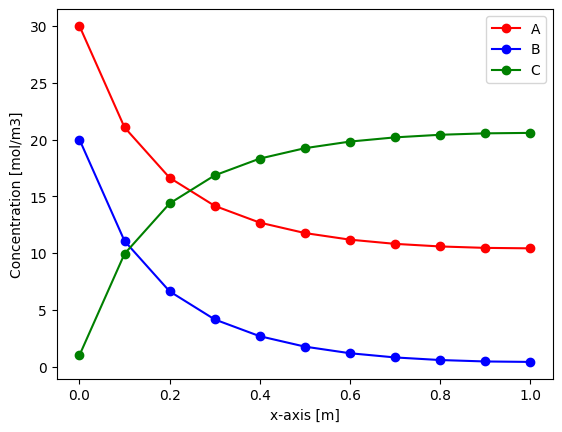

In [8]:
plt.plot(Model1.mesh.getXCoor(), Model1.sol['A'], '-or')
plt.plot(Model1.mesh.getXCoor(), Model1.sol['B'], '-ob')
plt.plot(Model1.mesh.getXCoor(), Model1.sol['C'], '-og')
plt.legend(['A', 'B', 'C'])

plt.xlabel("x-axis [m]")
plt.ylabel("Concentration [mol/m3]")